### Imports

In [1]:
import yfinance as yf

import numpy as np
import pandas as pd

import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, coint

import matplotlib.pyplot as plt

from pykalman import KalmanFilter

### Data

In [2]:
pairs = {
    # --- Broad Market ---
    'SPY/QQQ':   ('SPY',  'QQQ'),   # S&P 500 vs Nasdaq 100
    'SPY/IVV':   ('SPY',  'IVV'),   # S&P 500 vs iShares S&P 500 (near-identical, tight spread)
    'IWM/IWB':   ('IWM',  'IWB'),   # Russell 2000 (small) vs Russell 1000 (large)
    'QQQ/XLK':   ('QQQ',  'XLK'),   # Nasdaq 100 vs Tech sector

    # --- Sector ---
    'XLE/XOP':   ('XLE',  'XOP'),   # Energy broad vs oil & gas E&P
    'XLF/KBE':   ('XLF',  'KBE'),   # Financials broad vs banks
    'XLV/IBB':   ('XLV',  'IBB'),   # Healthcare broad vs biotech
    'XLU/IDU':   ('XLU',  'IDU'),   # Utilities SPDR vs iShares Utilities

    # --- Commodities ---
    'GDX/GDXJ':  ('GDX',  'GDXJ'),  # Senior vs Junior gold miners
    'GLD/SLV':   ('GLD',  'SLV'),   # Gold vs Silver (gold/silver ratio)
    'USO/BNO':   ('USO',  'BNO'),   # WTI crude vs Brent crude

    # --- Volatility / Defensive ---
    'SPY/GLD':   ('SPY',  'GLD'),   # Risk-on vs safe haven
    'IEF/GLD':   ('IEF',  'GLD'),   # Bonds vs Gold (both "flight to safety")
}

tickers = sorted({t for pair in pairs.values() for t in pair})
raw_train = yf.download(tickers, start='2018-01-01', end='2020-01-01')['Close'].dropna()
raw_test  = yf.download(tickers, start='2024-01-01', end='2025-01-01')['Close'].dropna()
prices_train = np.log(raw_train)
prices_test  = np.log(raw_test)

print(f"Train: {prices_train.index[0].date()} to {prices_train.index[-1].date()} ({len(prices_train)} days)")
print(f"Test:  {prices_test.index[0].date()} to {prices_test.index[-1].date()} ({len(prices_test)} days)")

[*********************100%***********************]  2 of 2 completed
[*********************100%***********************]  2 of 2 completed

Train: 2018-01-02 to 2019-12-31 (503 days)
Test:  2024-01-02 to 2024-12-31 (252 days)


### Pair Selection

In [3]:
def ols_spread(y, x):
    res = sm.OLS(y, sm.add_constant(x)).fit()
    alpha, beta = res.params
    spread = (y - (alpha + beta * x)).rename('spread')
    return spread, beta

def hurst(ts, max_lag=40):
    # H < 0.5 → mean-reverting, H = 0.5 → random walk, H > 0.5 → trending
    lags = range(2, max_lag)
    tau  = [np.std(ts[l:].values - ts[:-l].values) for l in lags]
    return np.polyfit(np.log(lags), np.log(tau), 1)[0]

def half_life(s):
    # Days for spread to revert halfway to mean
    s    = s.dropna()
    df   = pd.concat([s - s.shift(1), s.shift(1)], axis=1).dropna()
    df.columns = ['delta', 'lag']
    beta = sm.OLS(df['delta'], sm.add_constant(df['lag'])).fit().params['lag']
    return -np.log(2) / np.log(1 + beta) if beta < 0 else np.inf

def score_pair(name, a, b, prices):
    y, x    = prices[a], prices[b]
    sp, beta = ols_spread(y, x)
    return {
        'pair':      name, 'a': a, 'b': b,
        'beta':      round(beta, 4),
        'eg_pval':   round(coint(y, x)[1], 4),
        'adf_pval':  round(adfuller(sp.dropna())[1], 4),
        'hurst':     round(hurst(sp), 4),
        'half_life': round(half_life(sp), 2),
    }

results = pd.DataFrame(
    [score_pair(n, a, b, prices_train) for n, (a, b) in pairs.items()]
).set_index('pair')

mask = (
    (results['eg_pval']  < 0.05) &   # cointegrated pair
    (results['adf_pval'] < 0.05) &   # spread is stationary
    (results['hurst']    < 0.45) &   # mean-reverting
    results['half_life'].between(5, 30)  # tradeable reversion speed
)
results['status'] = np.where(mask, '✓', '✗')
selected = results[mask]

print(f"Selected {len(selected)}/{len(results)} pairs")
display(results.sort_values('status', ascending=False))

Selected 1/1 pairs


,a,b,beta,eg_pval,adf_pval,hurst,half_life,status
pair,,,,,,,,
SPY/QQQ,SPY,QQQ,0.7775,0.0156,0.0035,0.3923,14.36,✓


### Spread Models

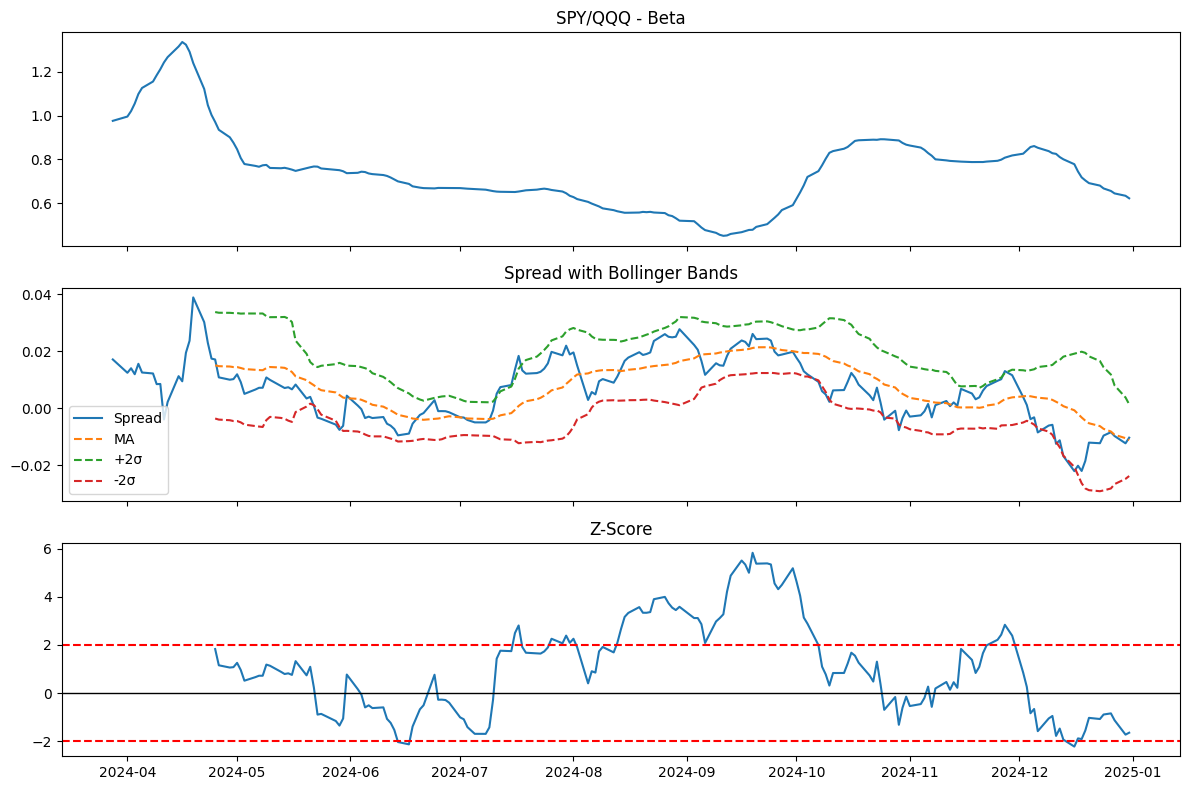

In [4]:
def static_ols(y, x):
    X = sm.add_constant(x)
    model = sm.OLS(y, X).fit()
    alpha = model.params['const']
    beta = model.params[x.name]
    spread = y - (alpha + beta * x)
    return beta, spread

def rolling_ols(y, x, window = 60):
    beta_series = pd.Series(index=y.index, dtype=float)
    spread_series = pd.Series(index=y.index, dtype=float)

    for i in range(window, len(y)):
        y_win = y.iloc[i-window:i]
        x_win = x.iloc[i-window:i]

        X = sm.add_constant(x_win)
        model = sm.OLS(y_win, X).fit()

        alpha = model.params.iloc[0]
        beta = model.params.iloc[1]

        spread = y.iloc[i] - (alpha + beta * x.iloc[i])

        beta_series.iloc[i] = beta
        spread_series.iloc[i] = spread
    
    return beta_series, spread_series

def kalman(y, x, delta=1e-5, R=1e-3):
    """
    Bayesian estimator
    2D Kalman filter for y = alpha + beta*x
    State = [alpha, beta]
    """

    n = len(y)

    state = np.zeros(2)  # alpha, beta
    P = np.eye(2) * 1e3   # uncertainty

    beta_series = pd.Series(index=y.index, dtype=float)
    spread_series = pd.Series(index=y.index, dtype=float)

    for t in range(n):
        xt = np.array([1.0, x.iloc[t]])

        # Prediction step
        P = P + delta * np.eye(2)

        # Observation
        y_pred = np.dot(xt, state)
        error = y.iloc[t] - y_pred

        # Kalman gain
        S = np.dot(xt, np.dot(P, xt)) + R
        K = np.dot(P, xt) / S

        # Update state
        state = state + K * error
        P = P - np.outer(K, np.dot(xt, P))

        alpha, beta = state

        beta_series.iloc[t] = beta
        spread_series.iloc[t] = y.iloc[t] - (alpha + beta * x.iloc[t])

    return beta_series, spread_series

def compute_zscore(spread, window=20):
    mean = spread.rolling(window).mean()
    std = spread.rolling(window).std()

    z = (spread) / std
    return z

def plot_pair(name, beta, spread, z):
    bb_window = 20
    ma = spread.rolling(bb_window).mean()
    std = spread.rolling(bb_window).std()

    upper = ma + 2 * std
    lower = ma - 2 * std
    
    fig, ax = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

    ax[0].plot(beta)
    ax[0].set_title(f"{name} - Beta")

    ax[1].plot(spread, label="Spread")
    ax[1].plot(ma, linestyle="--", label="MA")
    ax[1].plot(upper, linestyle="--", label="+2σ")
    ax[1].plot(lower, linestyle="--", label="-2σ")
    ax[1].set_title("Spread with Bollinger Bands")
    ax[1].legend()

    ax[2].plot(z)
    ax[2].axhline(0, color="black", linewidth=1)
    ax[2].axhline(2, linestyle="--", color="red")
    ax[2].axhline(-2, linestyle="--", color="red")
    ax[2].set_title("Z-Score")

    plt.tight_layout()
    plt.show()

for name, (a, b) in pairs.items():
    y = prices_test[a]
    x = prices_test[b]
    beta, spread = rolling_ols(y, x, window=60)
    z = compute_zscore(spread)
    plot_pair(name, beta, spread, z)

### Signal Generation

In [5]:
def generate_signals(z, entry=2, exit=0.5):
    signal = pd.Series(index=z.index, dtype=float)
    position = 0

    for i in range(len(z)):
        if np.isnan(z.iloc[i]):
            signal.iloc[i] = 0
            continue

        if position == 0:
            if z.iloc[i] > entry:
                position = -1   # short spread
            elif z.iloc[i] < -entry:
                position = 1    # long spread

        elif position == 1:
            if z.iloc[i] > -exit:
                position = 0

        elif position == -1:
            if z.iloc[i] < exit:
                position = 0

        signal.iloc[i] = position

    return signal

### Backtest

In [6]:
def backtest(spread, pos, cost=0.001, target_vol=0.15):
    spread_ret = spread.diff().fillna(0)
    
    realized_vol = spread_ret.rolling(20).std() * np.sqrt(252)
    vol_scale    = (target_vol / realized_vol.clip(lower=1e-8)).clip(upper=5)
    pos_scaled   = pos * vol_scale.shift(1)
    
    pnl = pos_scaled.shift(1).fillna(0) * spread_ret
    turnover = pos.diff().abs().fillna(0)
    pnl -= turnover * cost
    equity = pnl.cumsum()
    
    return pd.DataFrame({'pnl': pnl, 'equity': equity})

def metrics(bt, pos):
    pnl = bt['pnl']
    trades = pos.diff().abs().gt(0).sum()
    sharpe = pnl.mean() / (pnl.std() + 1e-8) * np.sqrt(252)
    ann_pnl = pnl.mean() * 252
    max_dd = (bt['equity'] - bt['equity'].cummax()).min()
    active = pnl[pos.shift(1).fillna(0) != 0]
    avg_hold = len(pos) / (trades + 1e-8)

    return pd.Series({
        'ann_pnl': ann_pnl,
        'sharpe': sharpe,
        'max_drawdown': max_dd,
        'win_rate': (active > 0).mean(),
        'n_trades': int(trades),
        'avg_hold': avg_hold,
    })

def run_strategy(y, x, model="ols"):
    if model == "static":
        beta, spread = static_ols(y, x)
    elif model == "rolling":
        beta, spread = rolling_ols(y, x, window=60)
    elif model == "kalman":
        beta, spread = kalman(y, x)
    else:
        raise ValueError("Unknown model")

    z = compute_zscore(spread, window=20)
    signal = generate_signals(z)
    bt = backtest(spread, signal)
    m = metrics(bt, signal)
    
    return m, bt["equity"]

In [7]:
models = ["static", "rolling", "kalman"]

results = []
equity_curves = {}

for name, (a, b) in pairs.items():
    y = prices_test[a]
    x = prices_test[b]

    for model in models:
        m, equity = run_strategy(y, x, model=model)
        m["pair"] = name
        m["model"] = model
        results.append(m)
        equity_curves[(name, model)] = equity

df = pd.DataFrame(results)
df = df[[
    "pair",
    "model",
    "sharpe",
    "ann_pnl",
    "max_drawdown",
    "win_rate",
    "n_trades",
    "avg_hold"
]]
df.sort_values(["sharpe"], ascending=False)

,pair,model,sharpe,ann_pnl,max_drawdown,win_rate,n_trades,avg_hold
2,SPY/QQQ,kalman,3.083098,0.183921,-0.013080,0.743590,24.0,10.5
1,SPY/QQQ,rolling,2.001657,0.177014,-0.050468,0.573333,9.0,28.0
0,SPY/QQQ,static,1.928071,0.236785,-0.056627,0.582192,15.0,16.8


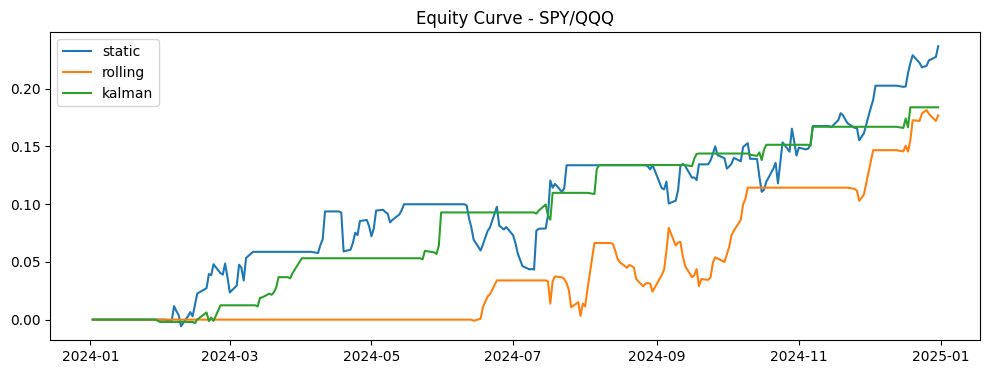

<Figure size 640x480 with 0 Axes>

In [9]:
for name, _ in pairs.items():
    plt.figure(figsize=(12, 4))

    for model in models:
        eq = equity_curves[(name, model)]
        plt.plot(eq, label=model)

    plt.title(f"Equity Curve - {name}")
    plt.legend()
    plt.show()